In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset limpio
df = pd.read_csv('../data/crude_oil_clean.csv')

# Eliminar clase con muy pocas muestras
df = df[df['TIPO_CRUDO'] != 'Extra pesado'].copy()

# Features y variable objetivo
features = ['SGRAV_CRUD', 'SRC', 'CRN', 'SU100', 
            'POUR_POINT', 'CAR_CR_WT', 'LT_GAS_VOL', 
            'GAS_NP_VOL', 'RESDUM_VOL']

X = df[features]
y = df['TIPO_CRUDO']

# Filtrar outliers extremos de viscosidad
X = X[X['SU100'] < 2000].copy()
y = y[X.index]

# Encodear variable objetivo
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Clases:", le.classes_)
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")
print("\nDistribución en train:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f"  {cls}: {cnt}")

Clases: ['Liviano' 'Mediano' 'Pesado']
Train: 7079 muestras
Test:  1770 muestras

Distribución en train:
  Liviano: 5450
  Mediano: 1178
  Pesado: 451


RANDOM FOREST — Resultados
              precision    recall  f1-score   support

     Liviano       1.00      1.00      1.00      1363
     Mediano       1.00      1.00      1.00       294
      Pesado       1.00      1.00      1.00       113

    accuracy                           1.00      1770
   macro avg       1.00      1.00      1.00      1770
weighted avg       1.00      1.00      1.00      1770



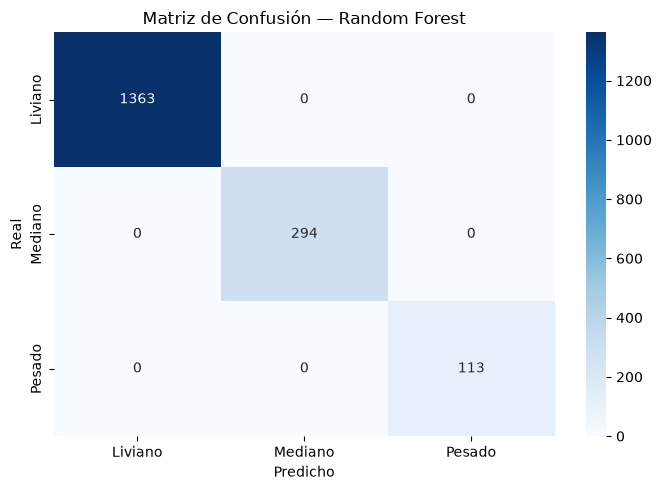

In [5]:
# Modelo 1: Random Forest (baseline)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  # compensa el desbalance de clases
)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Métricas
print("=" * 50)
print("RANDOM FOREST — Resultados")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Matriz de Confusión — Random Forest')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig('../data/confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()

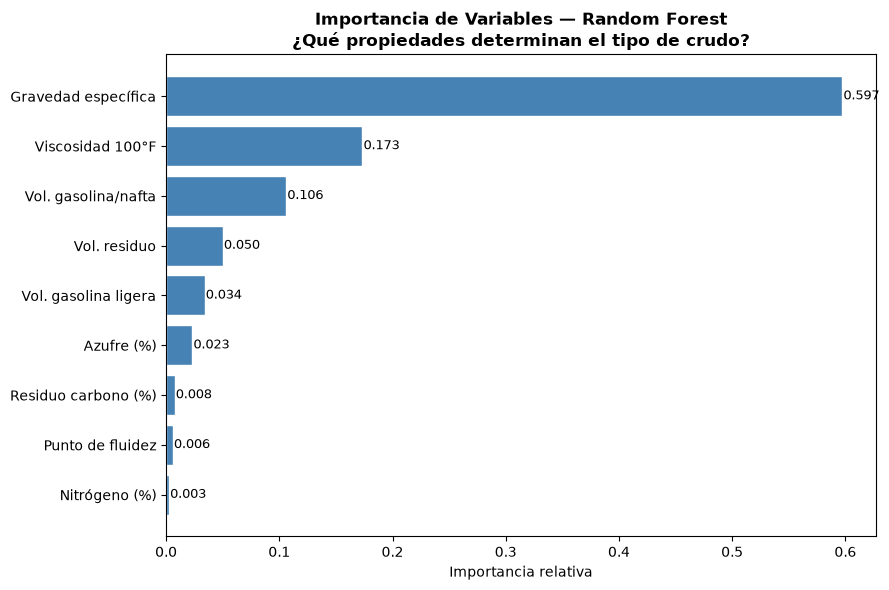

In [6]:
# Importancia de features — Random Forest
importancias = pd.DataFrame({
    'feature': features,
    'importancia': rf_model.feature_importances_
}).sort_values('importancia', ascending=True)

nombres_legibles = {
    'SGRAV_CRUD': 'Gravedad específica',
    'SRC': 'Azufre (%)',
    'CRN': 'Nitrógeno (%)',
    'SU100': 'Viscosidad 100°F',
    'POUR_POINT': 'Punto de fluidez',
    'CAR_CR_WT': 'Residuo carbono (%)',
    'LT_GAS_VOL': 'Vol. gasolina ligera',
    'GAS_NP_VOL': 'Vol. gasolina/nafta',
    'RESDUM_VOL': 'Vol. residuo'
}
importancias['feature'] = importancias['feature'].map(nombres_legibles)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importancias['feature'], importancias['importancia'],
               color='steelblue', edgecolor='white')
ax.set_title('Importancia de Variables — Random Forest\n¿Qué propiedades determinan el tipo de crudo?',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia relativa')
for bar, val in zip(bars, importancias['importancia']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()